# Make Figures

Kendra Wyant  
March 5, 2026

In [ ]:
#| include: false
#| message: false
#| warning: false

library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──
✔ broom        1.0.7      ✔ rsample      1.2.1 
✔ dials        1.2.1      ✔ tune         1.2.1 
✔ infer        1.0.7      ✔ workflows    1.1.4 
✔ modeldata    1.3.0      ✔ workflowsets 1.1.0 
✔ parsnip      1.2.1      ✔ yardstick    1.3.1 
✔ recipes      1.0.10     
── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Search for functions across packages at https://www.tidymodels.org/find/

ℹ SHA-1 hash of file is "0faa14c0c44c2635216370888b7da9bfa8d07979"

### Fairness

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?

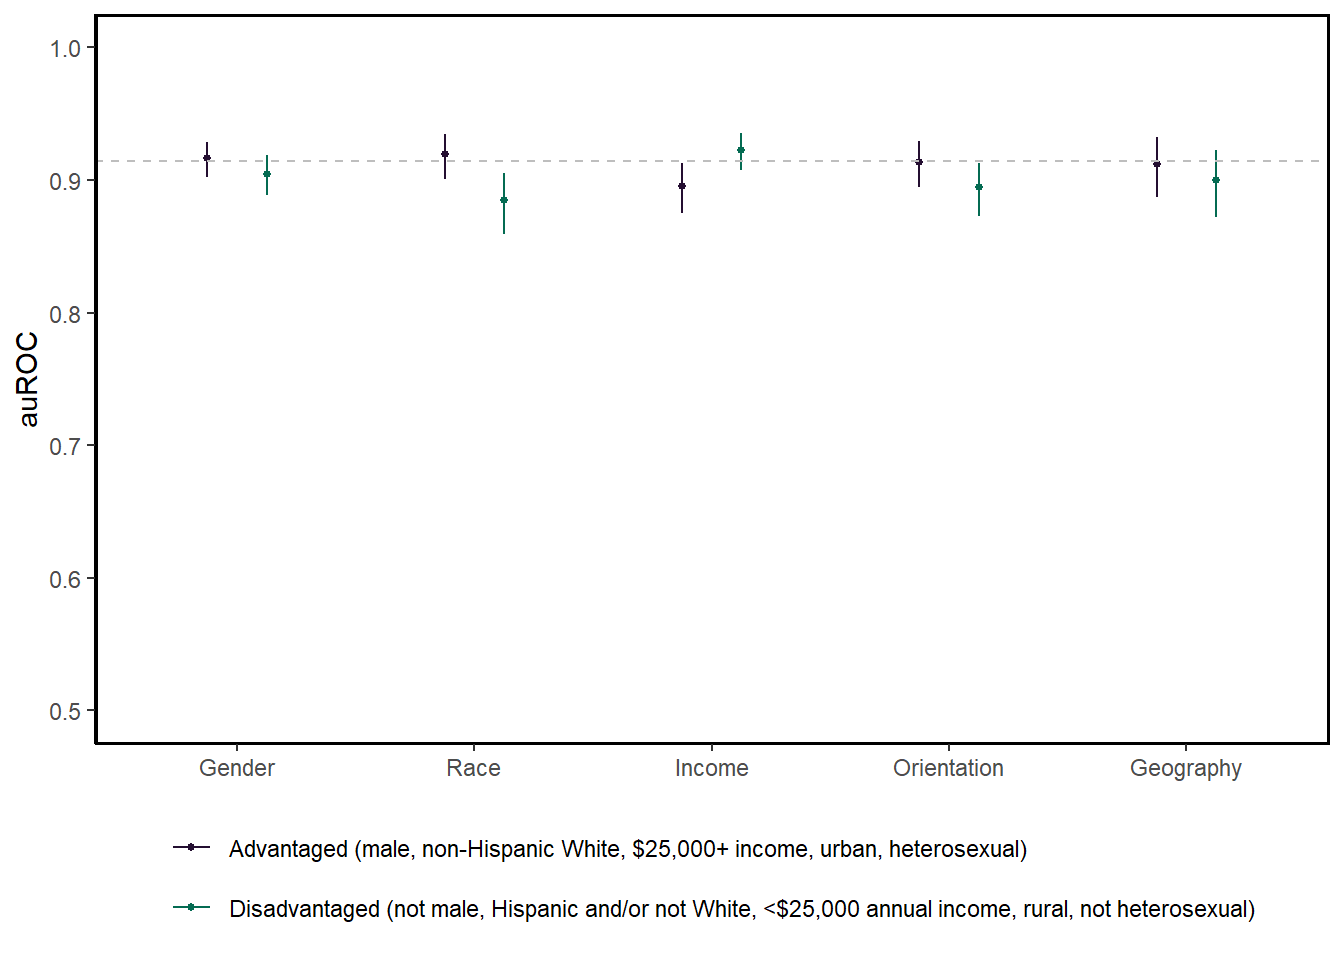

In [ ]:
#| label: fig-1
#| fig-cap: "Posterior probabilities for area under the receiver operating curve (auROC) by demographic subgroup. auROC ranges from .5 (chance performance) to 1 (perfect performance). Subgroups advantaged in access to substance use treatment and outcomes (male, non-Hispanic White, greater than $25,000 annual income, urban location, and heterosexual) are depicted in dark purple. Subgroups disadvantaged in access to substance use treatment and outcomes (not male, Hispanic and/or not White, less than $25,000 annual income, rural location, and not heterosexual) are depicted in green. Overall model performance across groups is depicted as the dashed grey line."
#| message: false
#| code-fold: true

pp_dem |>
  mutate(group = case_match(model,
                               "male" ~ "Gender",
                               "not male" ~ "Gender",
                               "non-Hispanic White" ~ "Race",
                               "Hispanic and/or not white" ~ "Race",
                               "below poverty" ~ "Income",
                               "above poverty" ~ "Income",
                               "urban/suburban" ~ "Geography",
                               "small town/rural" ~ "Geography",
                               "heterosexual" ~ "Orientation",
                               "not heterosexual" ~ "Orientation"),
         fairness = if_else(model %in% c("not male", 
                                         "Hispanic and/or not white",
                                         "below poverty",
                                         "small town/rural",
                                         "not heterosexual"), 
                            "Disadvantaged (not male, Hispanic and/or not White, <$25,000 annual income, rural, not heterosexual)",
                            "Advantaged (male, non-Hispanic White, $25,000+ income, urban, heterosexual)"),
         fairness = factor(fairness),
         group = factor(group, levels = c("Gender", "Race",
                                                "Income", "Orientation", "Geography"))) |>  
  ggplot(aes(x = group, y = pp_median, color = fairness)) + 
  geom_point(position = position_dodge(width = 0.5), size = 1) +
  geom_line(position = position_dodge(width = 0.5)) +
  geom_segment(mapping = aes(x = group, y = pp_lower, yend = pp_upper, color = fairness),
               position = position_dodge(width = 0.5)) +
  scale_y_continuous("auROC", limits = c(.50, 1.0)) +
  labs(x = NULL,
       color = NULL) +
  theme_classic() +
  theme(legend.position = "bottom",
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1)) +
  scale_color_manual(values = c("#240e31", "#046B52")) +
  geom_hline(yintercept = subset(pp_all, model == "full")$pp_median, linetype = "dashed",  color = "grey") +
guides(color = guide_legend(nrow = 2, byrow = TRUE))

### Calibration

In [ ]:
#| echo: false

bin_width = 0.10

preds_all_logi <- preds |> 
  mutate(bins = cut(prob_logi, breaks = seq(0, 1, bin_width)), 
         lapse = if_else(label == "Lapse", 1, 0),
         prob = "Platt calibration")  

preds_all_raw <- preds |> 
  mutate(bins = cut(prob_raw, breaks = seq(0, 1, bin_width)), 
         lapse = if_else(label == "Lapse", 1, 0),
         prob = "Raw (uncalibrated)") 

rug_data <- preds_all_raw |> 
  mutate(
    bins = as.numeric(bins),
    rug_center = bin_width/2 + bin_width * (bins - 1),
    rug_x = rug_center + runif(n(), -bin_width/2, bin_width/2)
  )

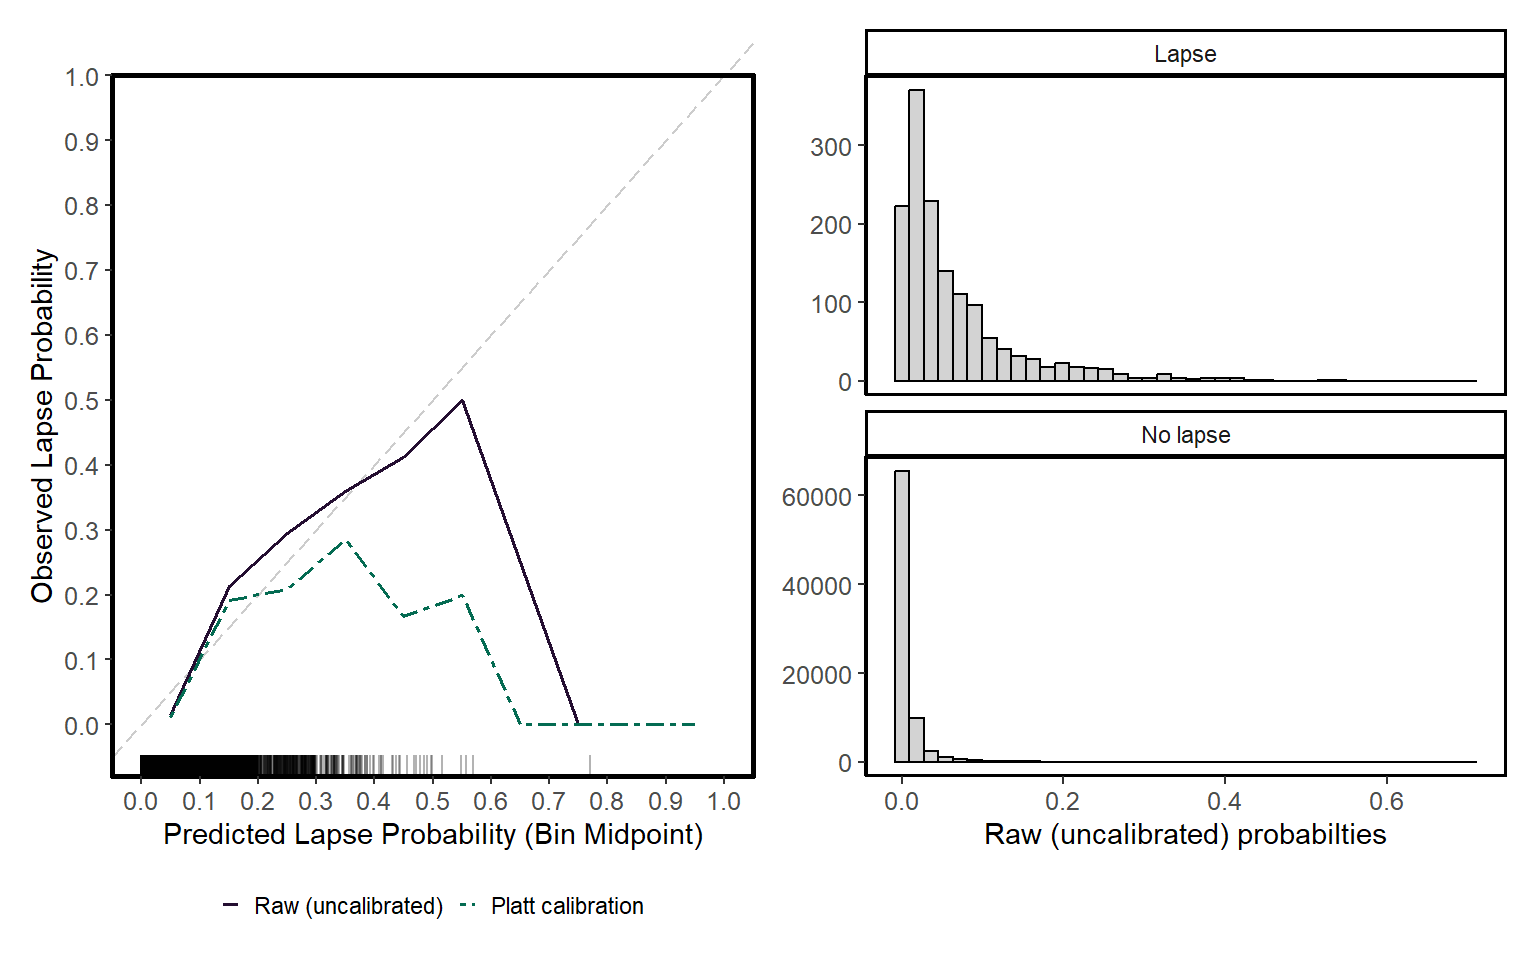

In [ ]:
#| label: fig-2
#| fig-cap: "The left panel presents a calibration plot of raw and Platt scaled risk probabilities. Predicted probabilities (x-axis) are binned into deciles. Observed lapse probability (y-axis) represents the proportion of actual lapses observed in each bin. The dashed diagonal represents perfect calibration. Points below the line indicate overestimation and points above the line indicate underestimation. Raw probabilities are depicted as the dark purple line. Platt calibrated probabilities are depicted as the green dashed line. The rug plot along the x-axis depicts observation frequency in each bin. The right panel presents histograms of raw (uncalibrated) risk probability distributions separately by true lapse outcome."
#| fig-width: 8

cal <- preds_all_raw |> 
  bind_rows(preds_all_logi) |> 
  mutate(prob = factor(prob, levels = c("Raw (uncalibrated)", 
                                        "Platt calibration"))) |> 
  group_by(bins,  prob)  |> 
  summarize(mean_lapse = mean(lapse),
            .groups = "drop") |> 
  mutate(
    bins = as.numeric(bins),
    midpoints = bin_width/2 + bin_width * (bins - 1)
  )  |> 
  ggplot(aes(x = midpoints, y = mean_lapse, group = prob,
             color = prob, linetype = prob)) +
  geom_abline(slope = 1, intercept = 0, linetype = "longdash", color = "gray80") +
  geom_line(linewidth = .7) +
  labs(
    x = "Predicted Lapse Probability (Bin Midpoint)",
    y = "Observed Lapse Probability",
    color = NULL,
    linetype = NULL
  ) +
  geom_rug(data = rug_data, aes(x = rug_x), sides = "b", alpha = 0.3,
           inherit.aes = FALSE) +
  scale_x_continuous(breaks = seq(0, 1, bin_width), limits = c(0, 1)) +
  scale_y_continuous(limits = c(-0.08, 1), breaks = seq(0,1, bin_width),
                     expand = c(0, 0)) +
  coord_cartesian(clip = "off") +
  scale_color_manual(values = c("#240e31", "#046B52")) +
  scale_linetype_manual(values = c("solid", "twodash")) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        legend.key.size = unit(0.25, "cm"),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1),
        legend.position = "bottom") 


hist <- preds |> 
  ggplot() +
  geom_histogram(aes(x = prob_raw), color = "black", 
                 fill = "light grey", bins = 40) +
  facet_wrap(~ label, ncol = 1, scales = "free_y") +
  labs(x = "Raw (uncalibrated) probabilties",
       y = NULL) +
  theme_classic() +
  theme(axis.text=element_text(size=9.5),
        panel.border = element_rect(colour = "black", fill = NA, linewidth = 1))

cal + hist